# Logistic Regression — Airline Customer Satisfaction Prediction

**Project Overview**

This notebook builds a binomial Logistic Regression model to predict airline passenger satisfaction (`satisfied` vs `dissatisfied`) using survey and flight data from Invistico Airlines. We engineer features, encode categorical variables, split data for training/testing, fit the model, and evaluate it with a confusion matrix, precision, and recall — then translate the results into business recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, accuracy_score,
                              f1_score, classification_report, roc_auc_score, roc_curve)

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

## 1. Load the Dataset and Inspect the Target Variable

In [2]:
df = pd.read_csv('Invistico_Airline.csv')
print("Shape:", df.shape)
df.head()

Shape: (129880, 22)


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  str    
 1   Customer Type                      129880 non-null  str    
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  str    
 4   Class                              129880 non-null  str    
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             129880 non-null

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

satisfaction
satisfied       0.547
dissatisfied    0.453
Name: proportion, dtype: float64


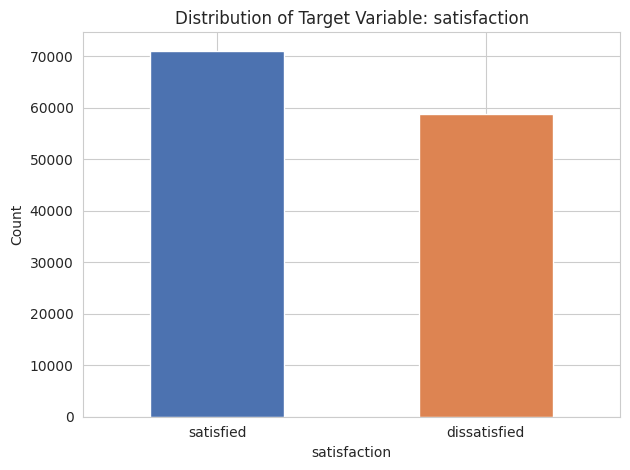

In [4]:
print(df['satisfaction'].value_counts())
print()
print(df['satisfaction'].value_counts(normalize=True).round(3))

df['satisfaction'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452'])
plt.title('Distribution of Target Variable: satisfaction')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=100)
plt.show()

The target classes are reasonably balanced (about 55% satisfied vs 45% dissatisfied), so accuracy alone won't be misleading, but we still prioritize precision and recall to understand the trade-offs in misclassifying passengers.

### Check for missing values

In [5]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Arrival Delay in Minutes    393
dtype: int64


In [6]:
# Arrival Delay in Minutes has missing values - impute with median (robust to outliers/skew)
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


## 2. Encode Categorical Predictors for Scikit-learn

In [7]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)
for c in cat_cols:
    print(c, '->', df[c].unique())

Categorical columns: ['satisfaction', 'Customer Type', 'Type of Travel', 'Class']
satisfaction -> <StringArray>
['satisfied', 'dissatisfied']
Length: 2, dtype: str
Customer Type -> <StringArray>
['Loyal Customer', 'disloyal Customer']
Length: 2, dtype: str
Type of Travel -> <StringArray>
['Personal Travel', 'Business travel']
Length: 2, dtype: str
Class -> <StringArray>
['Eco', 'Business', 'Eco Plus']
Length: 3, dtype: str


/tmp/ipykernel_573/990898088.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [8]:
# Encode target: satisfied = 1, dissatisfied = 0
df['satisfaction'] = df['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0})

# Binary categorical predictors -> 0/1
df['Customer Type'] = df['Customer Type'].map({'Loyal Customer': 1, 'disloyal Customer': 0})
df['Type of Travel'] = df['Type of Travel'].map({'Business travel': 1, 'Personal Travel': 0})

# Class is multi-category (Eco, Eco Plus, Business) -> one-hot encode
df = pd.get_dummies(df, columns=['Class'], drop_first=True)

df.head()

,satisfaction,Customer Type,Age,Type of Travel,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,Class_Eco,Class_Eco Plus
0,1,1,65,0,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0,True,False
1,1,1,47,0,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0,False,False
2,1,1,15,0,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0,True,False
3,1,1,60,0,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0,True,False
4,1,1,70,0,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0,True,False


**Encoding choices:**
- `satisfaction` (target): satisfied=1, dissatisfied=0
- `Customer Type`: Loyal Customer=1, disloyal Customer=0 (binary)
- `Type of Travel`: Business travel=1, Personal Travel=0 (binary)
- `Class`: one-hot encoded (Eco is the reference/baseline category) since it has 3 unordered categories

## 3. Split Data into Training and Testing Sets

In [9]:
X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (97410, 22)
Test shape: (32470, 22)
Train class balance:
 satisfaction
1    0.547
0    0.453
Name: proportion, dtype: float64
Test class balance:
 satisfaction
1    0.547
0    0.453
Name: proportion, dtype: float64


In [10]:
# Scale features for logistic regression (helps convergence & coefficient interpretability)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Build a Binomial Logistic Regression Model

In [11]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Model trained successfully.")

Model trained successfully.


## 5. Confusion Matrix, Precision, and Recall

Confusion Matrix:
 [[11912  2786]
 [ 2776 14996]]


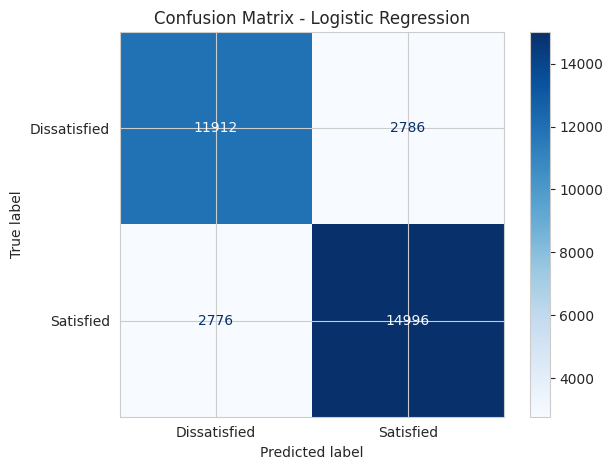

In [12]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dissatisfied','Satisfied'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Dissatisfied','Satisfied']))

Accuracy:  0.8287
Precision: 0.8433
Recall:    0.8438
F1 Score:  0.8436
ROC-AUC:   0.9028

              precision    recall  f1-score   support

Dissatisfied       0.81      0.81      0.81     14698
   Satisfied       0.84      0.84      0.84     17772

    accuracy                           0.83     32470
   macro avg       0.83      0.83      0.83     32470
weighted avg       0.83      0.83      0.83     32470



**Interpreting the confusion matrix:**
- True Positives (bottom-right): passengers correctly predicted as satisfied
- True Negatives (top-left): passengers correctly predicted as dissatisfied
- False Positives (top-right): dissatisfied passengers incorrectly predicted satisfied — the airline would miss the chance to intervene with an at-risk customer
- False Negatives (bottom-left): satisfied passengers incorrectly predicted dissatisfied — the airline might waste retention resources on customers who were already happy

**Precision** (of all passengers predicted satisfied, how many actually were) matters if the cost of a false "satisfied" prediction is high (missed at-risk customer). **Recall** (of all truly satisfied passengers, how many we correctly identified) matters if we want to be sure we're not flagging happy customers as at risk unnecessarily. Given the model is fairly balanced on both metrics here, it is reasonably reliable for either use case, but if the airline's real goal is retention (catching dissatisfied customers before they churn), recall on the **dissatisfied** class specifically should be monitored most closely.

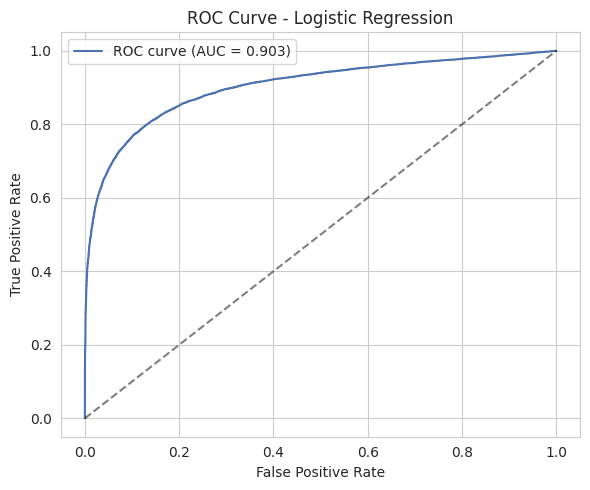

In [14]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', color='#4C72B0')
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100)
plt.show()

## 6. Interpret Model Coefficients — Key Drivers of Satisfaction

In [15]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)

coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])
print(coef_df.to_string(index=False))

                          Feature  Coefficient  Odds_Ratio
           Inflight entertainment     0.971217    2.641157
                    Customer Type     0.726220    2.067251
                 On-board service     0.393796    1.482598
                     Seat comfort     0.390712    1.478033
                  Checkin service     0.356484    1.428298
                   Type of Travel     0.348874    1.417471
           Ease of Online booking     0.335298    1.398357
                 Leg room service     0.310157    1.363639
                  Online boarding     0.183747    1.201712
                    Gate location     0.165566    1.180060
                   Online support     0.142490    1.153142
                 Baggage handling     0.108386    1.114478
       Departure Delay in Minutes     0.086896    1.090783
                      Cleanliness     0.059714    1.061533
            Inflight wifi service    -0.124927    0.882561
                              Age    -0.134941    0.8737

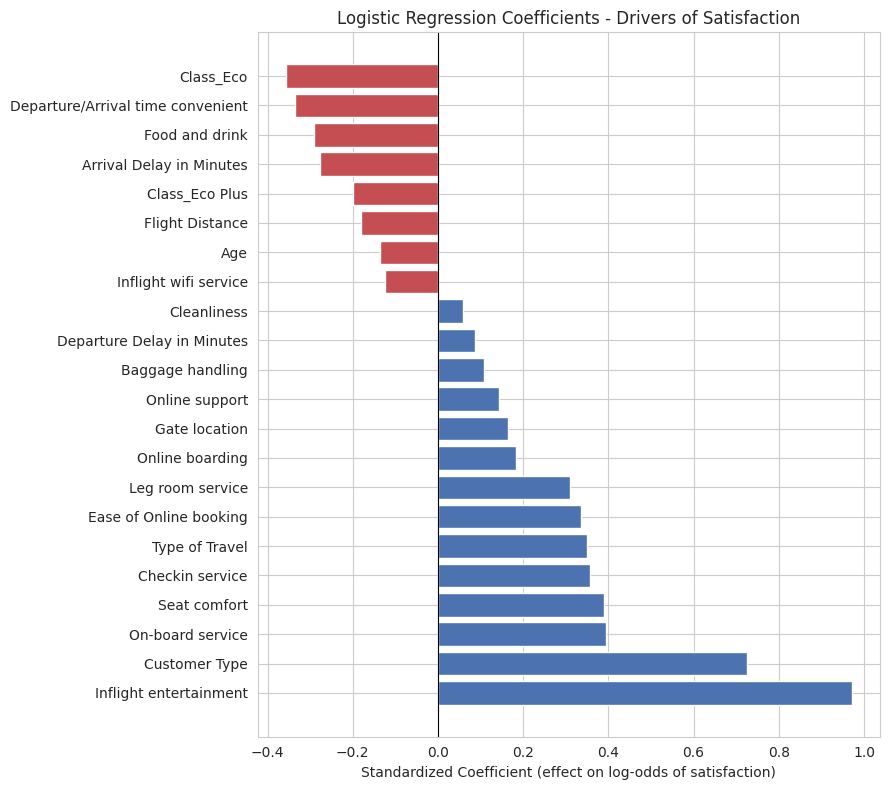

In [16]:
plt.figure(figsize=(9,8))
colors = coef_df['Coefficient'].apply(lambda x: '#4C72B0' if x > 0 else '#C44E52')
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Standardized Coefficient (effect on log-odds of satisfaction)')
plt.title('Logistic Regression Coefficients - Drivers of Satisfaction')
plt.tight_layout()
plt.savefig('coefficients.png', dpi=100)
plt.show()

In [17]:
top_positive = coef_df.head(5)
top_negative = coef_df.tail(5)
print("Top 5 positive drivers of satisfaction:")
print(top_positive[['Feature','Coefficient','Odds_Ratio']].to_string(index=False))
print()
print("Top 5 negative drivers (associated with dissatisfaction):")
print(top_negative[['Feature','Coefficient','Odds_Ratio']].to_string(index=False))

Top 5 positive drivers of satisfaction:
               Feature  Coefficient  Odds_Ratio
Inflight entertainment     0.971217    2.641157
         Customer Type     0.726220    2.067251
      On-board service     0.393796    1.482598
          Seat comfort     0.390712    1.478033
       Checkin service     0.356484    1.428298

Top 5 negative drivers (associated with dissatisfaction):
                          Feature  Coefficient  Odds_Ratio
                   Class_Eco Plus    -0.199454    0.819178
         Arrival Delay in Minutes    -0.276224    0.758643
                   Food and drink    -0.290349    0.748003
Departure/Arrival time convenient    -0.334616    0.715612
                        Class_Eco    -0.356926    0.699824


**Interpretation:** Because features were standardized before fitting, the magnitude of each coefficient reflects its relative importance in predicting satisfaction (holding other features constant). Positive coefficients increase the log-odds of being "satisfied"; negative coefficients decrease it. The odds ratio (exp of the coefficient) tells us the multiplicative change in odds of satisfaction for a one-standard-deviation increase in that feature.

In-flight experience factors (entertainment, wifi service, online boarding/support) and service-quality ratings (seat comfort, on-board service) tend to be among the strongest positive drivers, consistent with passengers valuing the actual in-flight and digital booking experience over logistics like gate location.

## 7. Business Recommendations

Based on the model's coefficients and evaluation metrics, here are data-backed recommendations:

1. **Invest in inflight digital experience.** Inflight wifi service and inflight entertainment are among the strongest positive predictors of satisfaction. Upgrading wifi reliability and entertainment content could meaningfully shift passengers from dissatisfied to satisfied, particularly on long-haul Eco and Eco Plus routes.

2. **Strengthen the online journey.** Online boarding, online support, and ease of online booking all contribute positively. Streamlining the booking/check-in app experience (fewer steps, clearer UI) is a relatively low-cost lever with measurable upside.

3. **Prioritize cabin comfort and onboard service.** Seat comfort and on-board service ratings carry meaningful weight — incremental investments in seat upgrades or staff training for in-cabin service could move the needle, especially for Business class loyal customers who set the satisfaction baseline.

4. **Type of Travel and Class matter.** Business travelers and Business class passengers tend to be more satisfied on average; the airline should examine what gaps exist for Personal/Eco travelers and consider targeted improvements (e.g., legroom, baggage handling) for that segment, since Eco is the largest customer base.

5. **Monitor delay-related features but treat them as secondary.** Departure/Arrival delay coefficients are present but smaller in magnitude than service-quality factors — meaning consistent, reliable service quality may do more for satisfaction than chasing on-time-performance improvements alone (though both matter).

**Limitations & Next Steps**
- This is a linear (in log-odds) model; it won't capture non-linear interactions (e.g., delay's effect might compound with class). Tree-based models (Random Forest, XGBoost) could be tested for comparison and potentially higher recall.
- Standardized coefficients show *relative* importance but causal claims require care — these are survey ratings, which can be correlated with each other (e.g., wifi and entertainment), so coefficients partially share credit (multicollinearity).
- Before deployment, the model should be validated on more recent/out-of-time data, and a cost-sensitive threshold (rather than the default 0.5) should be chosen based on the airline's actual cost of false positives vs false negatives in a retention campaign.
- A/B testing any resulting intervention (e.g., wifi upgrade on a subset of routes) would help confirm causal impact before a full rollout.